# Lab 3 — Filtering & Edge Detection
**Student name:** Joud Thaher

**Course:** Computer Vision


same as before — shared outputs folder structure. images are in ../data/ and outputs go to ../outputs/. let me start with the setup and imports.

---
## Task 1 — Instructor-led: Setup, image preparation, and first filtering steps

### 1.1 Imports and helper setup

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("../outputs", exist_ok=True)
%matplotlib inline

this lab builds on what we learned in labs 1 and 2. now we're moving into filtering and edge detection. the key here is that we'll look at **both the image output AND the histogram** together — that connection between visual changes and intensity distribution is super important to understand what's happening.

in this lab i need to look at histograms for every operation because filtering changes the intensity distribution in different ways. smoothing will compress the distribution, edge detection will create mostly dark or bright pixels, etc.

### 1.2 Define display helpers with histograms

In [2]:
def show_image(img, title="Image", cmap=None, figsize=(6, 6)):
    """Display image with histogram underneath.
    
    For grayscale: one histogram showing intensity distribution
    For color: three histograms (R, G, B channels)
    """
    plt.figure(figsize=figsize)
    
    # Display the image
    plt.subplot(2, 1, 1)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    
    # Display histogram(s)
    plt.subplot(2, 1, 2)
    if img.ndim == 2:
        plt.hist(img.ravel(), bins=256, range=[0, 256])
        plt.title("Histogram")
        plt.xlabel("Intensity value")
        plt.ylabel("Number of pixels")
    else:
        plt.hist(img[:, :, 0].ravel(), bins=256, range=[0, 256], alpha=0.5, label="Red")
        plt.hist(img[:, :, 1].ravel(), bins=256, range=[0, 256], alpha=0.5, label="Green")
        plt.hist(img[:, :, 2].ravel(), bins=256, range=[0, 256], alpha=0.5, label="Blue")
        plt.title("Color channel histograms")
        plt.xlabel("Intensity value")
        plt.ylabel("Number of pixels")
        plt.legend()
    
    plt.tight_layout()
    plt.show()

In [3]:
def show_images(images, titles, cmap=None, figsize=(15, 7)):
    """Display multiple images side by side, each with histogram below.
    
    This lets me compare filtering effects across multiple images at once.
    """
    n = len(images)
    plt.figure(figsize=figsize)
    
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        # Image row
        plt.subplot(2, n, i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis("off")
        
        # Histogram row
        plt.subplot(2, n, n + i)
        if img.ndim == 2:
            plt.hist(img.ravel(), bins=256, range=[0, 256])
            plt.title("Histogram")
            plt.xlabel("Intensity")
            plt.ylabel("Count")
        else:
            plt.hist(img[:, :, 0].ravel(), bins=256, range=[0, 256], alpha=0.5, label="R")
            plt.hist(img[:, :, 1].ravel(), bins=256, range=[0, 256], alpha=0.5, label="G")
            plt.hist(img[:, :, 2].ravel(), bins=256, range=[0, 256], alpha=0.5, label="B")
            plt.title("Channel histograms")
            plt.xlabel("Intensity")
            plt.ylabel("Count")
            plt.legend()
    
    plt.tight_layout()
    plt.show()

i'm defining these helpers first because every time i show an image i want to see its histogram immediately below. this makes it much easier to connect what i see visually with what's happening in the intensity distribution.

### 1.3 Load the images

In [4]:
# Load color images in BGR
lenna_bgr = cv2.imread("../data/lenna.png")
baboon_bgr = cv2.imread("../data/baboon.png")

# Load barbara directly as grayscale
barbara_gray = cv2.imread("../data/barbara.png", cv2.IMREAD_GRAYSCALE)

print("Lenna shape:", lenna_bgr.shape)
print("Baboon shape:", baboon_bgr.shape)
print("Barbara shape:", barbara_gray.shape)

Lenna shape: (512, 512, 3)
Baboon shape: (512, 512, 3)
Barbara shape: (512, 512)


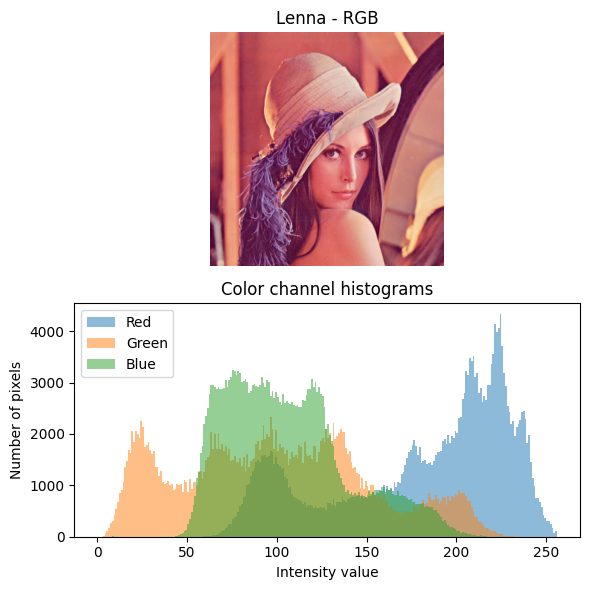

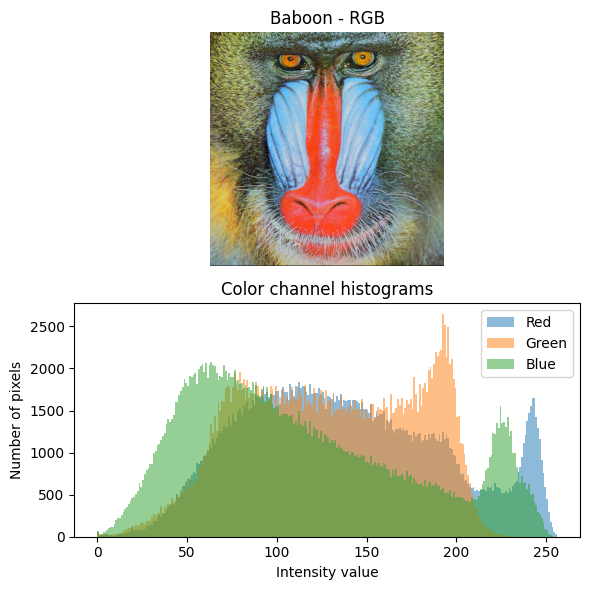

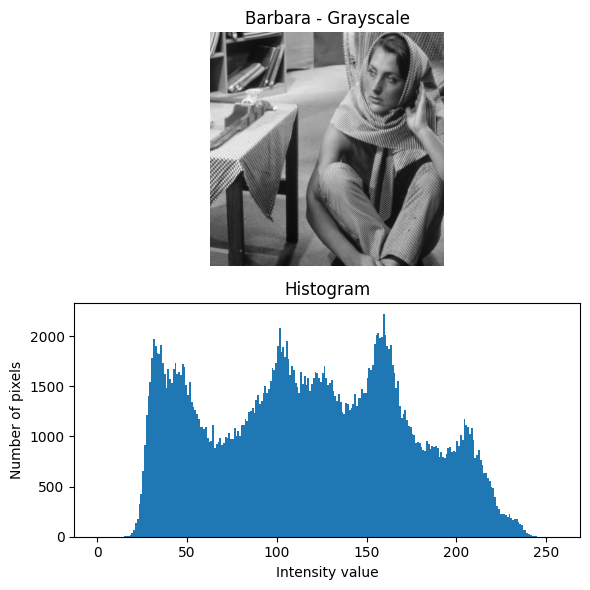

In [5]:
# Convert BGR to RGB for correct display
lenna_rgb = cv2.cvtColor(lenna_bgr, cv2.COLOR_BGR2RGB)
baboon_rgb = cv2.cvtColor(baboon_bgr, cv2.COLOR_BGR2RGB)

# Also create grayscale versions since we'll use them for filtering
lenna_gray = cv2.cvtColor(lenna_bgr, cv2.COLOR_BGR2GRAY)
baboon_gray = cv2.cvtColor(baboon_bgr, cv2.COLOR_BGR2GRAY)

show_image(lenna_rgb, "Lenna - RGB")
show_image(baboon_rgb, "Baboon - RGB")
show_image(barbara_gray, "Barbara - Grayscale", cmap="gray")

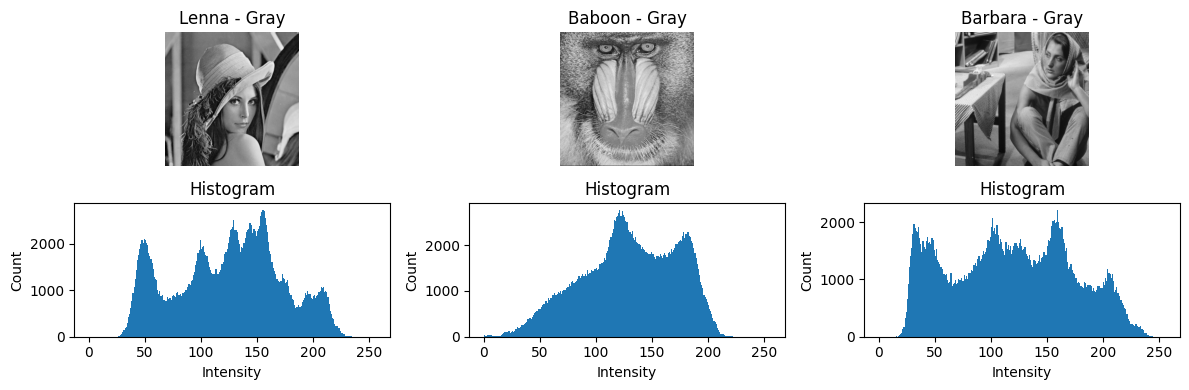

In [6]:
# Show all grayscale versions together for comparison
show_images(
    [lenna_gray, baboon_gray, barbara_gray],
    ["Lenna - Gray", "Baboon - Gray", "Barbara - Gray"],
    cmap="gray",
    figsize=(12, 4)
)

**what i notice:**
- lenna and baboon are color images so their histograms show 3 channels (R, G, B) with different distributions
- barbara is already grayscale, so just one histogram
- lenna has kind of a smooth histogram (it's a face, mostly mid-range skin tones)
- baboon has more texture and sharp features, so its histogram is more spread out
- barbara as a grayscale image shows a single peak — must have a specific texture

this is the baseline. now i'm ready to start filtering.

### 1.4 Understand convolution-based filtering

the key idea behind linear filtering is that we move a small matrix (kernel) across the image. at each position, we combine nearby pixels to make a new output pixel. this is **different** from point-wise operations where each output only depends on the corresponding input pixel.

smoothing filters work by averaging nearby pixels — this reduces noise and sharp transitions.

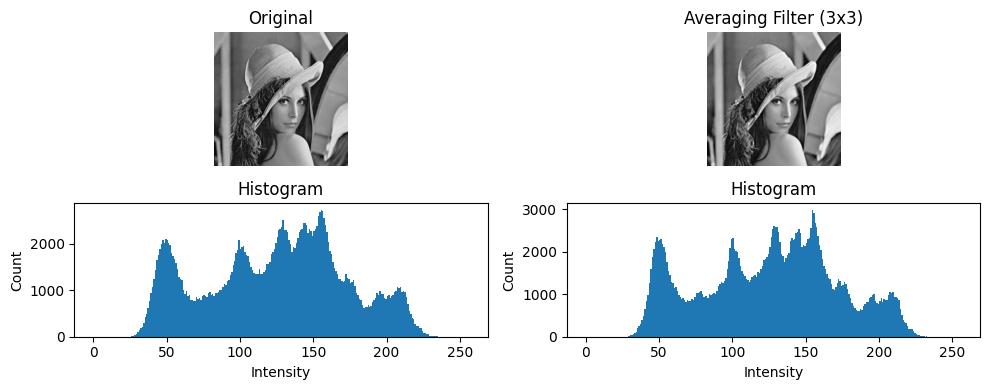

In [7]:
# Define a simple averaging (box) filter
# Each pixel gets the average of itself and its 8 neighbors (3x3 neighborhood)
avg_kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)

# Apply the filter to lenna grayscale
# cv2.filter2D applies a kernel to an image through convolution
lenna_blur_avg = cv2.filter2D(lenna_gray, -1, avg_kernel)

show_images(
    [lenna_gray, lenna_blur_avg],
    ["Original", "Averaging Filter (3x3)"],
    cmap="gray",
    figsize=(10, 4)
)

**what i observe:**
- the averaged version is noticeably softer — fine details like wrinkles and textures are less sharp
- the histogram from the blurred version is compressed — peaks are less extreme
- this makes sense because averaging reduces local variation in intensity
- edges (sharp transitions) get weaker because pixels at boundaries are now pulled toward their neighbors' values

this is the foundation. now i'm ready for the actual tasks.

---
## Task 2 — Group work: Smoothing, noise removal, and custom linear filters

### 2.1 Add noise and smooth with Gaussian filter

In [8]:
def add_gaussian_noise(img, sigma=20):
    """Add Gaussian noise to an image for testing denoising.
    
    sigma controls the strength of the noise (standard deviation).
    Higher sigma = more noise.
    """
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255)  # keep values in valid range
    return noisy.astype(np.uint8)

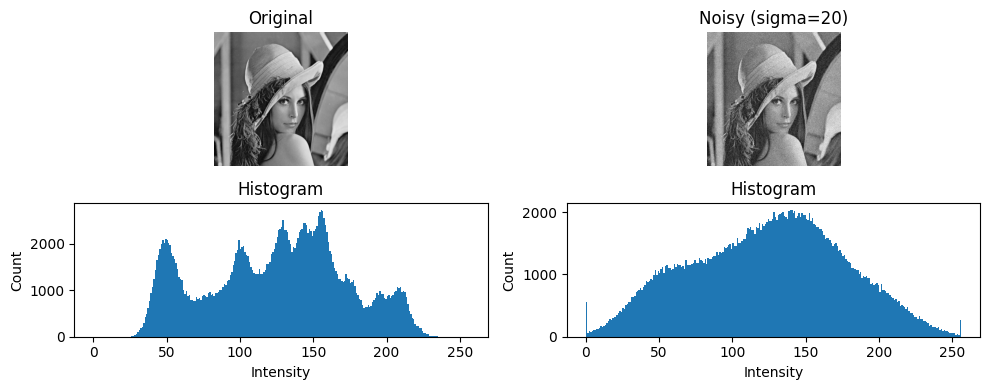

In [9]:
# Add noise to lenna and observe what happens
lenna_noisy = add_gaussian_noise(lenna_gray, sigma=20)

show_images(
    [lenna_gray, lenna_noisy],
    ["Original", "Noisy (sigma=20)"],
    cmap="gray",
    figsize=(10, 4)
)

**what i see:**
- the noisy version looks grainy — there are random bright and dark spots all over
- the histogram is now much wider and flatter — the noise spreads pixel values across the full 0-255 range
- the original smooth face now has a "salt and pepper" look
- this is what real camera images look like sometimes (especially in low light)

now let's see if we can clean it up with Gaussian smoothing.

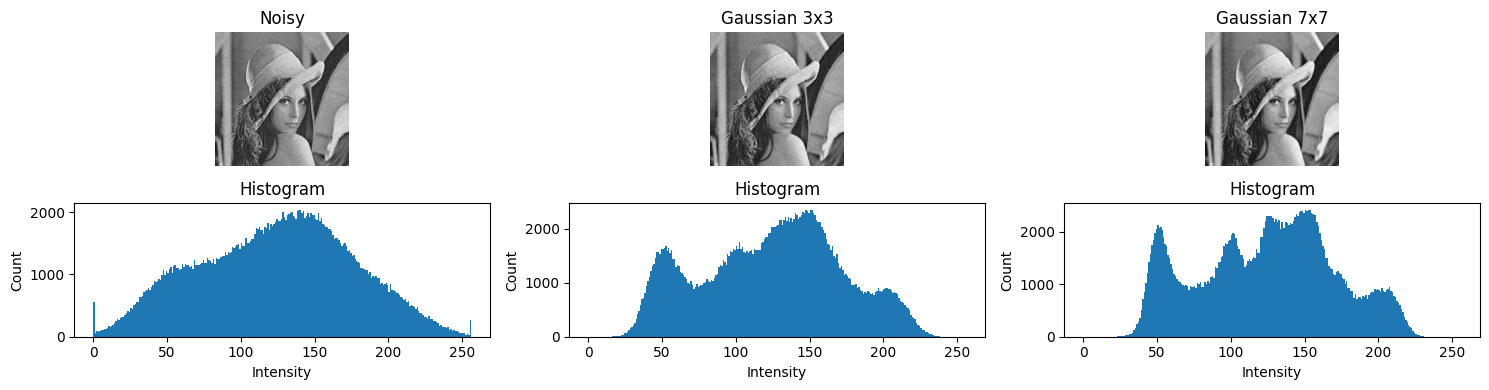

In [10]:
# Apply Gaussian blur with different kernel sizes
lenna_gauss_3 = cv2.GaussianBlur(lenna_noisy, (3, 3), 0)
lenna_gauss_7 = cv2.GaussianBlur(lenna_noisy, (7, 7), 0)

show_images(
    [lenna_noisy, lenna_gauss_3, lenna_gauss_7],
    ["Noisy", "Gaussian 3x3", "Gaussian 7x7"],
    cmap="gray",
    figsize=(15, 4)
)

**what i observe:**
- 3x3 Gaussian: the noise is less grainy but still visible. the histogram is compressed compared to the noisy version but still wider than the original
- 7x7 Gaussian: much smoother, noise is mostly gone. BUT fine details (like facial features) are now blurry. the histogram is back to something closer to the original
- **trade-off:** bigger filter = more denoising but also more detail loss
- the Gaussian gives more weight to the center and less to neighbors, so it's better than simple box averaging

i had to decide — do i want noise gone or do i want to see the face clearly? with real images, this is a real choice you have to make.

In [11]:
# Save the results
cv2.imwrite("../outputs/lenna_noisy.png", lenna_noisy)
cv2.imwrite("../outputs/lenna_gaussian_3x3.png", lenna_gauss_3)
cv2.imwrite("../outputs/lenna_gaussian_7x7.png", lenna_gauss_7)

print("Saved denoising results to outputs folder")

Saved denoising results to outputs folder


**Discussion: Noise removal vs detail preservation**

1. **Which filtered image looks cleaner?** The 7x7 clearly. Almost all grain is gone.

2. **Which loses more detail?** Again, the 7x7. Your face becomes a blob. The 3x3 keeps more of the original structure.

3. **Is there a trade-off?** 100% yes. You can't have everything — maximal noise removal requires blurring, which softens edges. In practice, you pick the size based on what matters more for your application.

4. **Histogram changes?** 
   - Original: relatively concentrated (face pixels are similar)
   - Noisy: spread out and flat (noise adds random values everywhere)
   - After Gaussian: back to something like the original but still slightly wider (some noise remains in the 3x3 case)
   - This makes sense: smoothing pulls all pixels toward their neighbors' average, compressing the distribution

### 2.2 Build some simple custom linear filters

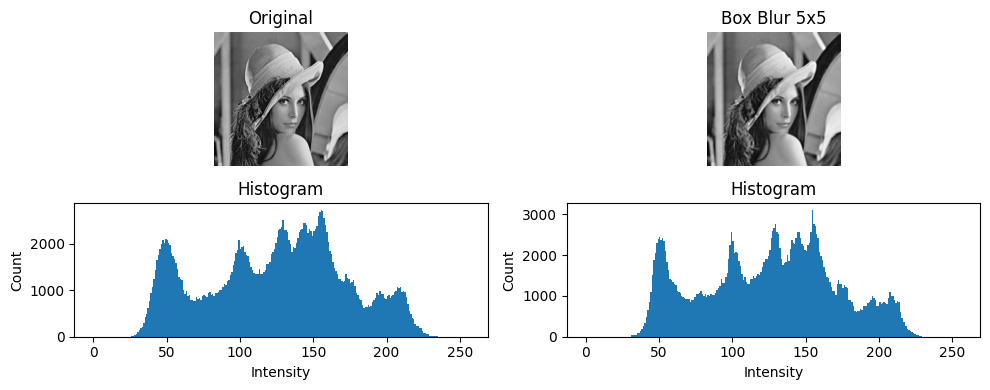

In [12]:
# A stronger blur kernel (5x5 instead of 3x3)
box5 = np.ones((5, 5), dtype=np.float32) / 25.0
lenna_box5 = cv2.filter2D(lenna_gray, -1, box5)

show_images(
    [lenna_gray, lenna_box5],
    ["Original", "Box Blur 5x5"],
    cmap="gray",
    figsize=(10, 4)
)

**observation:** the 5x5 box blur is stronger than the 3x3. facial features are even more blurred. the histogram peak is narrower — the 5x5 pulls more pixels toward the average so there's less variation.

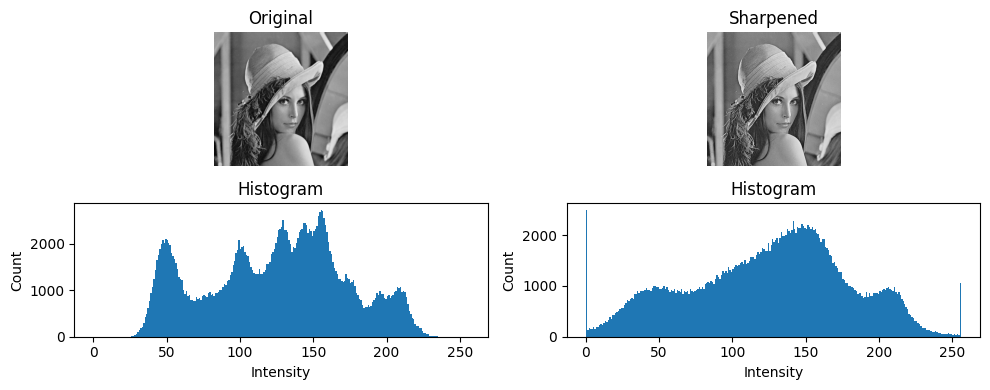

In [13]:
# A sharpening kernel
# This kernel emphasizes the difference between the center and its neighbors
sharp_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

# Apply sharpening to original lenna
lenna_sharp = cv2.filter2D(lenna_gray, -1, sharp_kernel)

show_images(
    [lenna_gray, lenna_sharp],
    ["Original", "Sharpened"],
    cmap="gray",
    figsize=(10, 4)
)

**wow, that's different:**
- the sharpened image looks crisp — edges are more defined, wrinkles stand out more
- very close to an edge detection output
- the histogram is now bimodal (two peaks) — more dark pixels and more bright pixels, fewer mid-range
- this makes sense: sharpening amplifies differences, so boundaries get darker (or brighter) depending on which side you're on

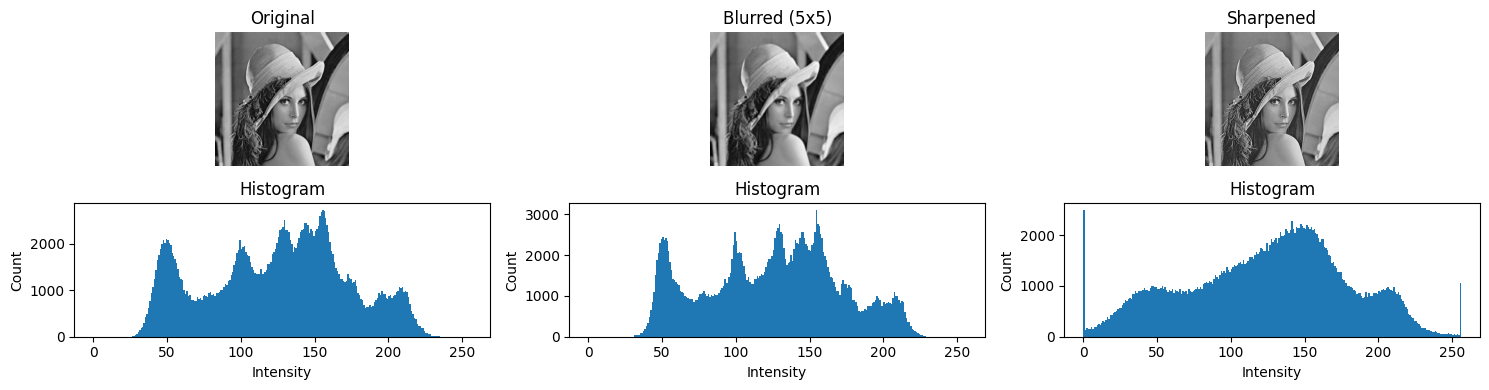

In [14]:
# Compare all three: original, blurred, sharpened
show_images(
    [lenna_gray, lenna_box5, lenna_sharp],
    ["Original", "Blurred (5x5)", "Sharpened"],
    cmap="gray",
    figsize=(15, 4)
)

**side-by-side comparison:**
- blurring removes fine detail but makes the image smoother
- sharpening adds contrast at edges, making them pop
- original is in the middle — balanced

### 2.3 Repeat blur and sharpen on another image

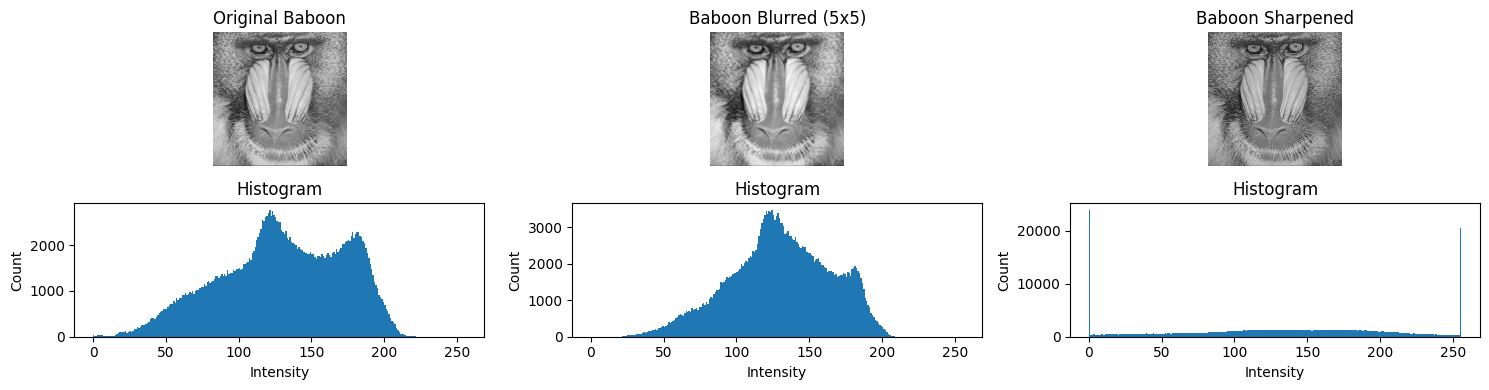

In [15]:
# Try the same thing on baboon (more texture, more interesting)
baboon_box5 = cv2.filter2D(baboon_gray, -1, box5)
baboon_sharp = cv2.filter2D(baboon_gray, -1, sharp_kernel)

show_images(
    [baboon_gray, baboon_box5, baboon_sharp],
    ["Original Baboon", "Baboon Blurred (5x5)", "Baboon Sharpened"],
    cmap="gray",
    figsize=(15, 4)
)

**comparing to lenna:**
- baboon has way more texture (fur, fur, fur everywhere)
- blurring baboon removes a LOT of that texture — the fur becomes a smooth blob
- sharpening baboon makes the texture even crazier — each hair-like feature gets exaggerated
- baboon's histogram changes are more dramatic because there's more local variation to begin with
- lenna is mostly smooth skin so changes are more subtle

**Discussion: Effects of blur and sharpening**

1. **What details become weaker after blur?** Fine structures — textures, edges, small features. Anything that requires neighboring pixels to be different gets smoothed away.

2. **What details become stronger after sharpening?** Edges and boundaries. Places where intensity changes quickly. High-frequency components of the image.

3. **Does sharpening also make noise more visible?** YES! If the original had any noise, sharpening would amplify it. That's why you usually denoise first, then sharpen. In this case, our images are clean, so sharpening just emphasizes real edges.

4. **Histogram after blur?** Compressed, narrower. Values get pulled toward the local average. Less spread.

5. **Histogram after sharpening?** More spread, more extreme values (darker darks, lighter lights). Differences get amplified.

These observations apply to both lenna and baboon, but the effect is more dramatic on baboon because it has more texture to work with.

---
## Task 3 — Group work: Sobel and Canny edge detection

### 3.1 Detect edges using Sobel filters

Edges happen where intensity changes fast. The Sobel operator computes **gradients** — how quickly the image intensity is changing in different directions. It gives us two outputs:
- Sobel X: changes in the horizontal direction
- Sobel Y: changes in the vertical direction

Combining them tells us where the strongest edges are overall.

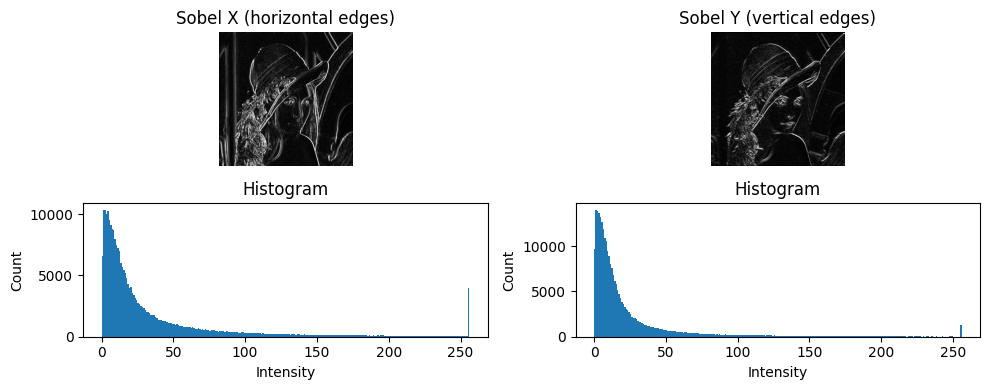

In [16]:
# Compute Sobel gradients
# cv2.CV_64F means we use 64-bit floating point (keeps precision during calculation)
# 1, 0 means: horizontal derivative (x-direction)
# 0, 1 means: vertical derivative (y-direction)
# ksize=3 means 3x3 kernel

sobel_x = cv2.Sobel(lenna_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(lenna_gray, cv2.CV_64F, 0, 1, ksize=3)

# Take absolute values (we care about magnitude, not direction sign)
sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y)

show_images(
    [sobel_x_abs, sobel_y_abs],
    ["Sobel X (horizontal edges)", "Sobel Y (vertical edges)"],
    cmap="gray",
    figsize=(10, 4)
)

**what i see:**
- Sobel X highlights vertical edges (places where left and right differ) — the left and right sides of the face, edges of features
- Sobel Y highlights horizontal edges (places where top and bottom differ) — eyebrows, mouth, chin
- both look mostly dark with bright lines where edges are
- the histograms are very skewed — most pixels are 0 (no edge) and a few are bright (edge pixels)

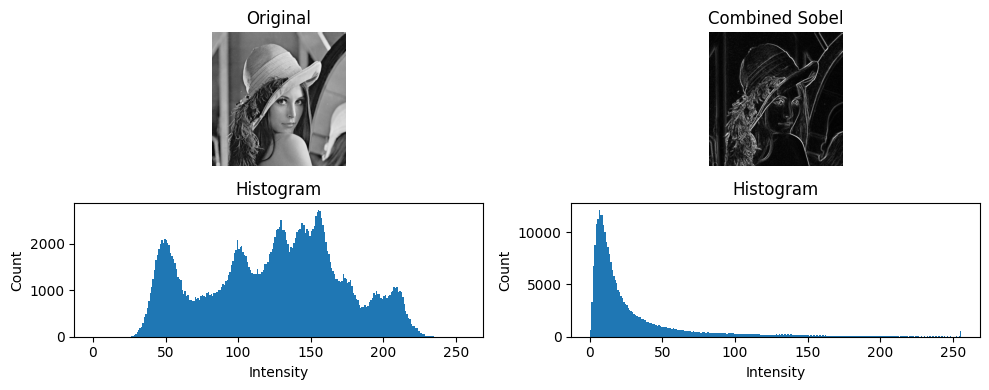

In [17]:
# Combine both directions
# We can simply average them (50/50 weight)
sobel_combined = cv2.addWeighted(sobel_x_abs, 0.5, sobel_y_abs, 0.5, 0)

show_images(
    [lenna_gray, sobel_combined],
    ["Original", "Combined Sobel"],
    cmap="gray",
    figsize=(10, 4)
)

**observation:**
- combined Sobel shows edges everywhere they exist
- face outline is clear, features are clear
- background is mostly black (no edges there)
- histogram is still very skewed — mostly black pixels with a tail of bright edge pixels

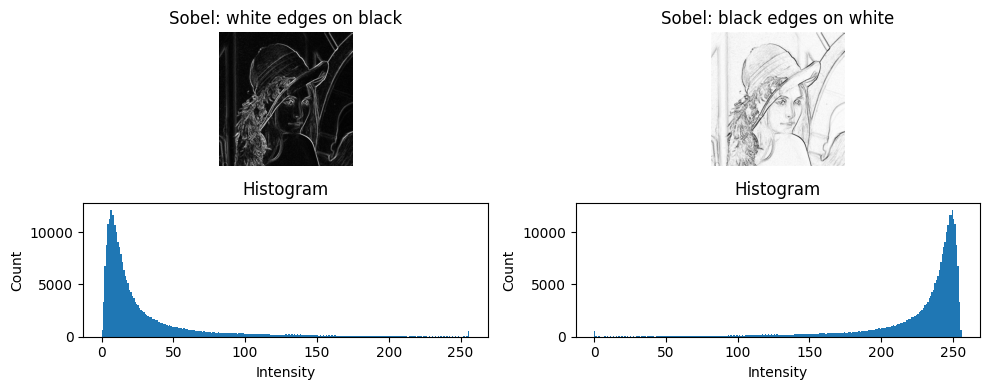

In [18]:
# Display edges on white background instead of black
# This is just: 255 - edge_map (invert)
sobel_inverted = 255 - sobel_combined

show_images(
    [sobel_combined, sobel_inverted],
    ["Sobel: white edges on black", "Sobel: black edges on white"],
    cmap="gray",
    figsize=(10, 4)
)

**important note:** inverting doesn't change where the edges ARE. it's just visualization. both versions have the same edge map, just displayed differently. i personally find the white-background version easier to read sometimes.

In [19]:
# Save results
cv2.imwrite("../outputs/lenna_sobel_x.png", sobel_x_abs)
cv2.imwrite("../outputs/lenna_sobel_y.png", sobel_y_abs)
cv2.imwrite("../outputs/lenna_sobel_combined.png", sobel_combined)
cv2.imwrite("../outputs/lenna_sobel_inverted.png", sobel_inverted)
print("Sobel outputs saved")

Sobel outputs saved


**Discussion: Sobel observations**

1. **Which structures are emphasized by Sobel?** Places where intensity changes quickly. Edges, boundaries, shadows, facial features. Basically any sharp transition in brightness.

2. **Difference between X and Y?** X catches vertical edges (left-right boundaries), Y catches horizontal edges (top-bottom boundaries). The two are perpendicular — they're looking at different directions.

3. **Does inverted version change the result?** No, it's purely visual. The data is the same, just displayed upside down in terms of brightness.

4. **How does the histogram differ from the original?** 
   - Original: smooth distribution centered around skin tones
   - Sobel: extremely skewed — almost all pixels at 0 (black background) with just a spike at the edge values
   - Most of the image is background (no edges), so the histogram is dominated by 0

### 3.2 Understand and apply the Canny pipeline

Canny edge detection has multiple stages:
1. Smooth the image (reduce noise)
2. Compute gradients (Sobel in both directions)
3. Compute gradient magnitude and direction
4. Thin edges using non-maximum suppression
5. Use double thresholding + hysteresis to decide which edges to keep

Let me trace through these steps to understand what's happening.

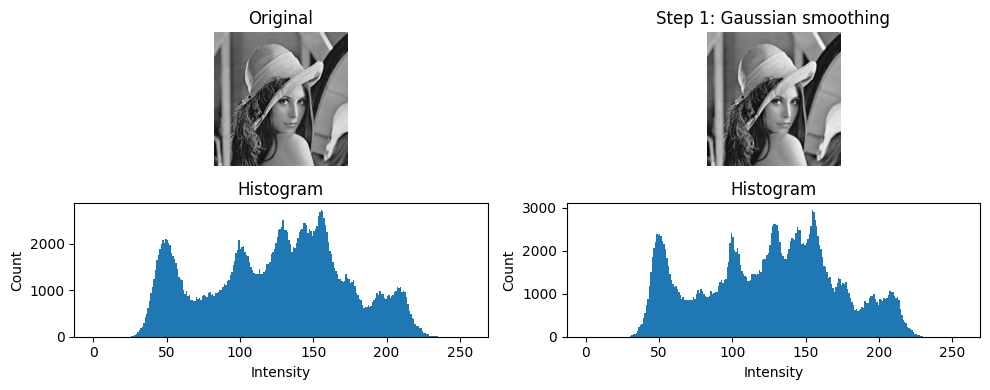

In [20]:
# Step 1: Smooth the image
# Canny always starts with smoothing to reduce noise effects
canny_blur = cv2.GaussianBlur(lenna_gray, (5, 5), 1)

show_images(
    [lenna_gray, canny_blur],
    ["Original", "Step 1: Gaussian smoothing"],
    cmap="gray",
    figsize=(10, 4)
)

**observation:** the pre-smoothing makes the image softer, just like we saw before. this removes small noise that would otherwise create false edges.

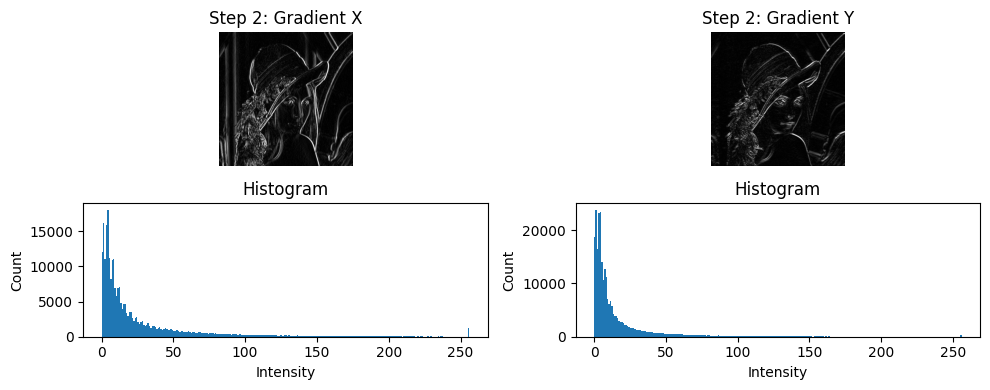

In [21]:
# Step 2: Compute gradients in x and y
grad_x = cv2.Sobel(canny_blur, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(canny_blur, cv2.CV_64F, 0, 1, ksize=3)

grad_x_abs = cv2.convertScaleAbs(grad_x)
grad_y_abs = cv2.convertScaleAbs(grad_y)

show_images(
    [grad_x_abs, grad_y_abs],
    ["Step 2: Gradient X", "Step 2: Gradient Y"],
    cmap="gray",
    figsize=(10, 4)
)

**observation:** same as basic Sobel — X and Y gradients show edges in their respective directions.

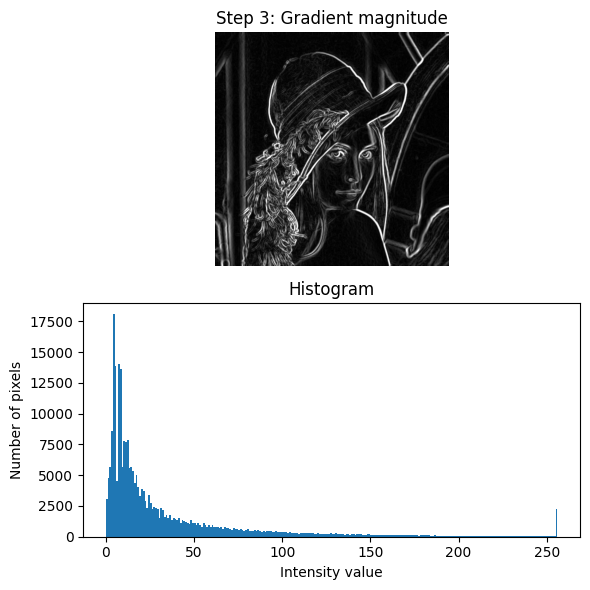

Gradient direction shape: (512, 512) (note: we don't visualize direction)


In [22]:
# Step 3: Compute gradient magnitude and direction
# Magnitude tells us the strength of the edge
# Direction tells us the angle (which we won't visualize here)

grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
grad_magnitude = np.clip(grad_magnitude, 0, 255).astype(np.uint8)

grad_direction = np.arctan2(grad_y, grad_x)

show_image(grad_magnitude, "Step 3: Gradient magnitude", cmap="gray", figsize=(6, 6))
print("Gradient direction shape:", grad_direction.shape, "(note: we don't visualize direction)")

**observation:** 
- magnitude combines both x and y into one map — shows how strong the edge is, regardless of direction
- places with high gradient = strong transitions = likely edges
- direction is stored but we don't look at it directly — Canny uses it internally for the thinning step

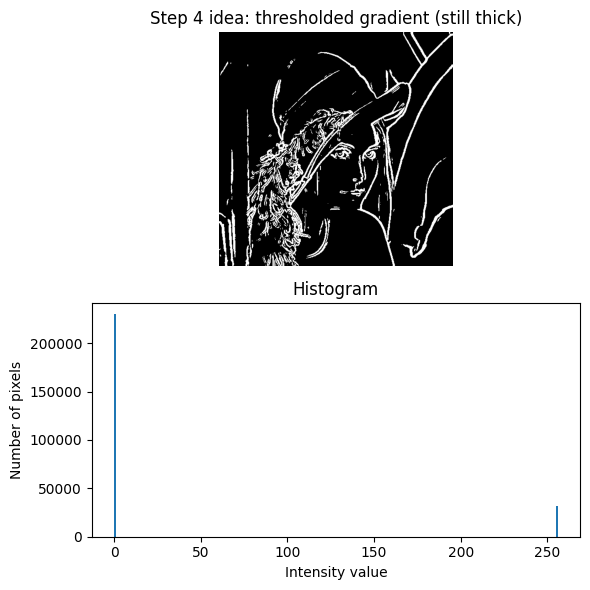

In [23]:
# Step 4: Edge thinning (non-maximum suppression)
# This is complex to implement from scratch, so i'll show a simple threshold instead
# The threshold-based version shows what edges would look like without thinning

# Let's use a threshold of 80
thick_edges = (grad_magnitude > 80).astype(np.uint8) * 255

show_image(thick_edges, "Step 4 idea: thresholded gradient (still thick)", cmap="gray")

**observation:** the thresholded gradient is "thick" — edges are multiple pixels wide. real edge detection software uses non-maximum suppression to thin this down to single-pixel-wide lines. but that algorithm is complex, so we just understand the concept here.

the idea is: along each edge, keep only the locally strongest pixel and suppress the others.

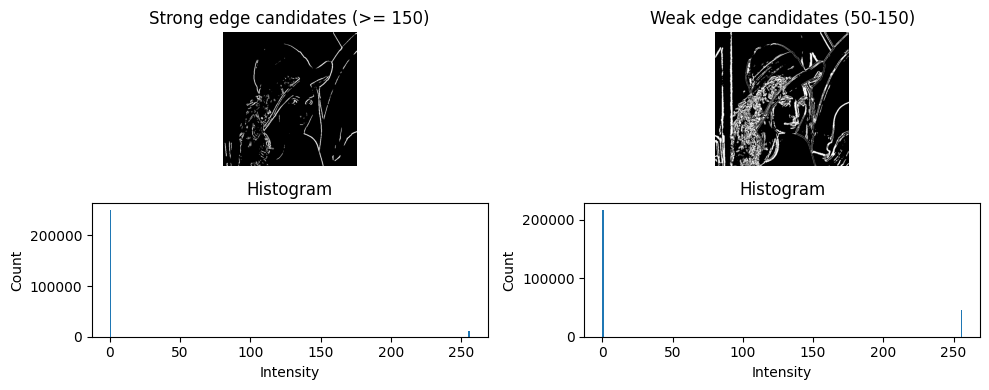

In [24]:
# Step 5: Double thresholding and hysteresis
# In the final stage, Canny decides:
# - high threshold: definitely edges (keep them)
# - low threshold: maybe edges IF they're connected to a definite edge
# - below low: definitely not edges (discard them)

low_thresh = 50
high_thresh = 150

strong = (grad_magnitude >= high_thresh).astype(np.uint8) * 255
weak = ((grad_magnitude >= low_thresh) & (grad_magnitude < high_thresh)).astype(np.uint8) * 255

show_images(
    [strong, weak],
    ["Strong edge candidates (>= 150)", "Weak edge candidates (50-150)"],
    cmap="gray",
    figsize=(10, 4)
)

**observation:**
- strong edges are the clear boundaries (face outline, feature edges)
- weak edges are the "maybe" pixels (texture, shading transitions)
- hysteresis means: keep weak edges ONLY if they connect to strong edges
- this gives Canny the ability to be flexible — it can follow edges even if they briefly drop below the high threshold, as long as they're connected to stronger edges

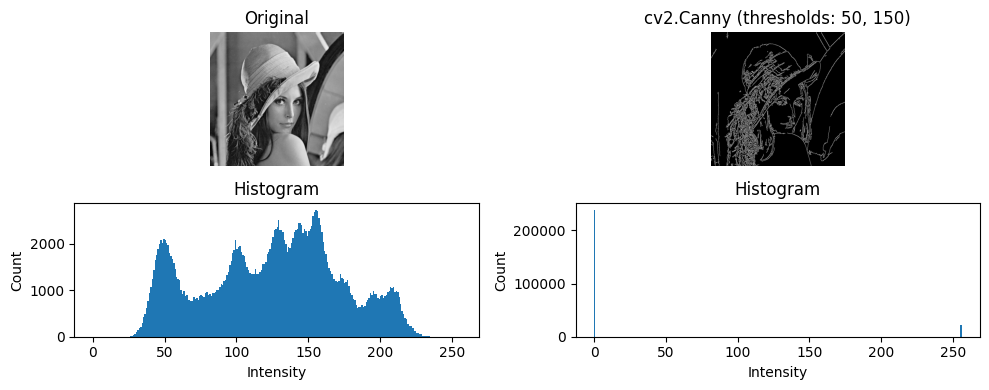

In [25]:
# Now apply the built-in OpenCV Canny detector
# It handles all 5 steps internally
canny_50_150 = cv2.Canny(lenna_gray, 50, 150)

show_images(
    [lenna_gray, canny_50_150],
    ["Original", "cv2.Canny (thresholds: 50, 150)"],
    cmap="gray",
    figsize=(10, 4)
)

**observation:**
- the final Canny output is MUCH cleaner than our simple Sobel
- edges are thin (one or two pixels wide thanks to non-maximum suppression)
- only the important edges are kept
- histogram is extreme: almost all 0 (black background) with just a few bright edge pixels

this is the final product.

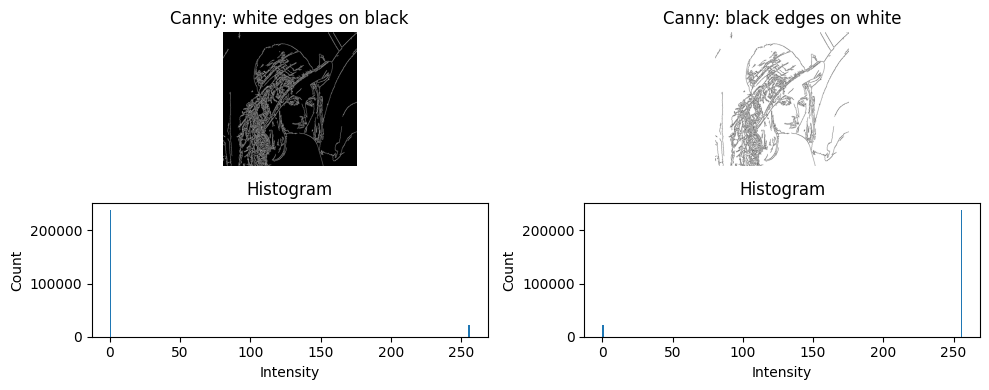

In [26]:
# Show Canny with inverted colors too
canny_inverted = 255 - canny_50_150

show_images(
    [canny_50_150, canny_inverted],
    ["Canny: white edges on black", "Canny: black edges on white"],
    cmap="gray",
    figsize=(10, 4)
)

**observation:** same as Sobel inverted — just a visualization preference.

### 3.3 Compare different threshold settings in Canny

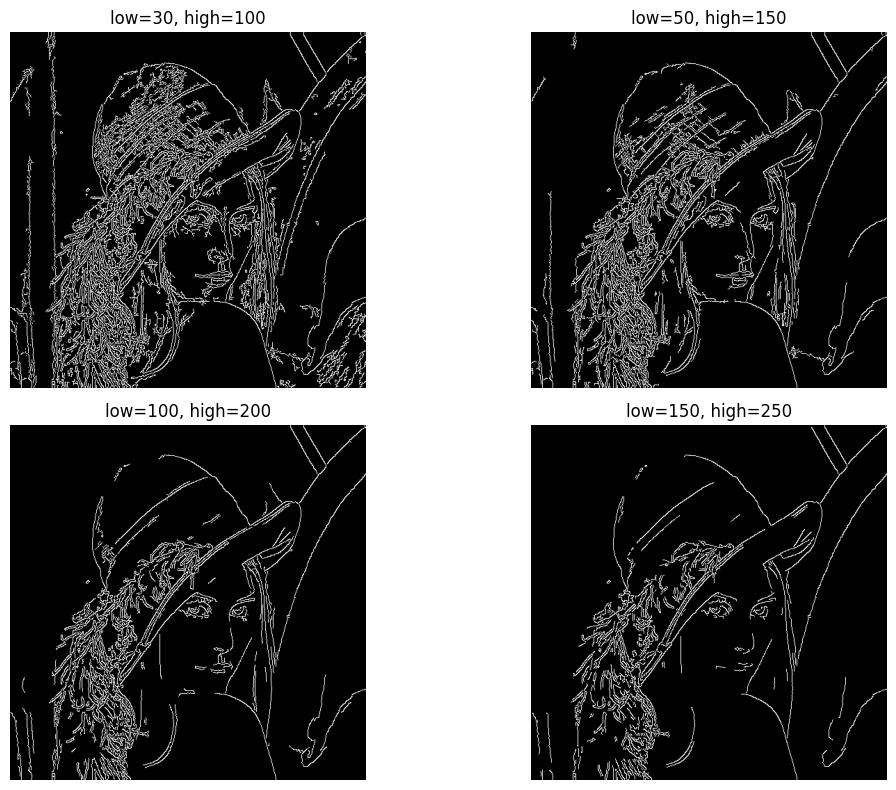

In [27]:
# The thresholds (low, high) control how many edges you keep
# Lower thresholds = more edges (including noise)
# Higher thresholds = fewer edges (but cleaner)

threshold_pairs = [
    (30, 100),
    (50, 150),
    (100, 200),
    (150, 250)
]

plt.figure(figsize=(12, 8))
for i, (low, high) in enumerate(threshold_pairs, start=1):
    edges = cv2.Canny(lenna_gray, low, high)
    plt.subplot(2, 2, i)
    plt.imshow(edges, cmap="gray")
    plt.title(f"low={low}, high={high}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**what i see:**
- (30, 100): Lots of edges everywhere. Fine textures, shading, subtle features all show up. Very detailed but also noisy.
- (50, 150): More balanced. Main structural edges are clear, less clutter.
- (100, 200): Only the strongest edges remain. Face outline is clear, features are obvious, but some detail is lost.
- (150, 250): Very sparse. Only the most dramatic edges. Clean but might miss important details.

the choice depends on what you need. for object detection, sparse is good. for analyzing texture, you might want lower thresholds.

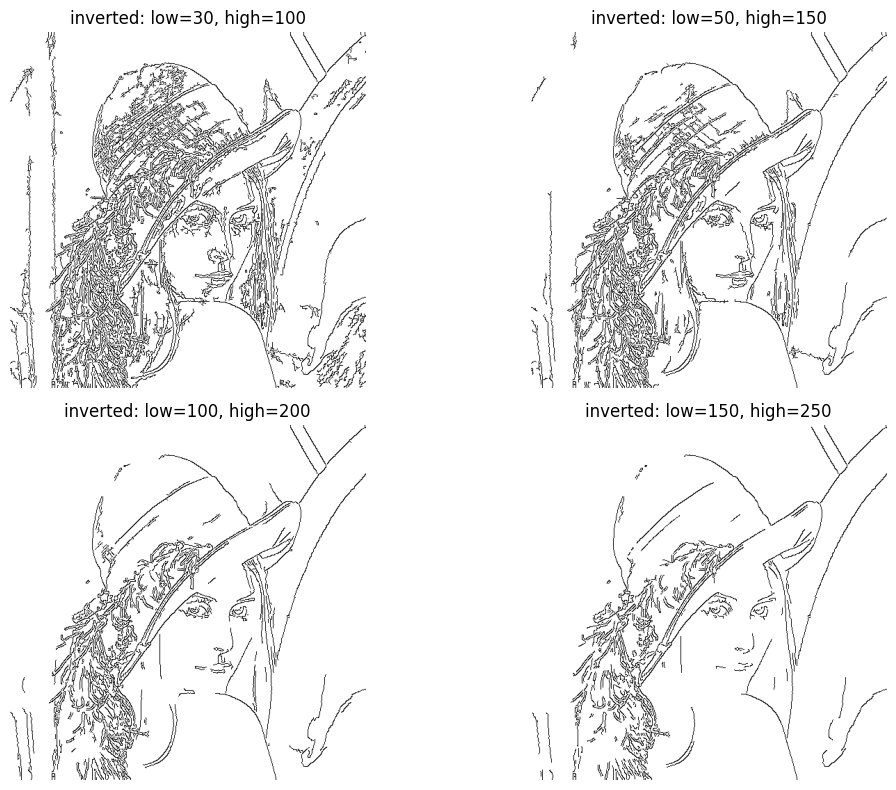

In [28]:
# Show the same with inverted colors (black edges on white)
plt.figure(figsize=(12, 8))
for i, (low, high) in enumerate(threshold_pairs, start=1):
    edges = cv2.Canny(lenna_gray, low, high)
    edges_inv = 255 - edges
    plt.subplot(2, 2, i)
    plt.imshow(edges_inv, cmap="gray")
    plt.title(f"inverted: low={low}, high={high}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**observation:** now edges are black on white — some people find this easier to read. but it's the same data.

**Discussion: Canny thresholds**

1. **What happens when thresholds are lower?** More edges appear. The algorithm becomes more permissive. You get more detail but also more noise and false positives.

2. **What happens when thresholds are higher?** Fewer edges. Only the strongest transitions survive. Result is cleaner and less cluttered.

3. **Which setting keeps important edges while removing unwanted weak edges?** That depends on your image and application. For lenna, i'd say (100, 200) is a good middle ground — solid edges without too much texture noise.

4. **How do histograms differ across these Canny results?** All four are heavily skewed toward 0 (black background). The lower-threshold versions have slightly more non-zero pixels (more edge pixels). But the distribution is similar — almost binary (either background or edge).

This is the key trade-off in edge detection: sensitivity vs specificity. You can't have both.

---
## Task 4 — Group work: Pyramid construction and one complete mini-experiment

### 4.1 Build a simple image pyramid step by step

A pyramid is a sequence of images at different scales/resolutions. The idea is simple:
1. Start with the fine (full resolution) image
2. Smooth it
3. Downsample (shrink) it by a factor of 2
4. Repeat 2-3

**Key:** smooth BEFORE downsampling. This prevents aliasing and information loss.

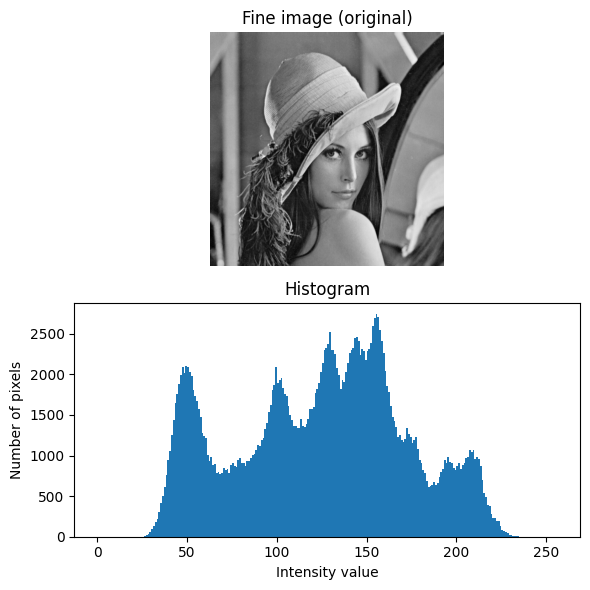

Fine shape: (512, 512)


In [29]:
# Start from lenna grayscale (fine level)
fine = lenna_gray.copy()

show_image(fine, "Fine image (original)", cmap="gray")
print("Fine shape:", fine.shape)

**observation:** this is the baseline — full resolution, all detail preserved.

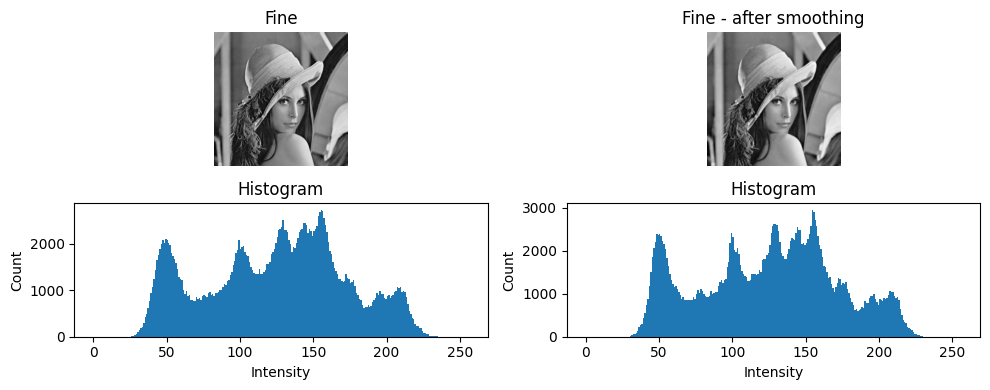

In [30]:
# Create the medium level
# Step 1: Smooth
fine_smooth = cv2.GaussianBlur(fine, (5, 5), 1)

show_images(
    [fine, fine_smooth],
    ["Fine", "Fine - after smoothing"],
    cmap="gray",
    figsize=(10, 4)
)

**observation:** smoothing softens the image slightly. histograms are compressed. the peak is higher (more pixels pushed toward the average).

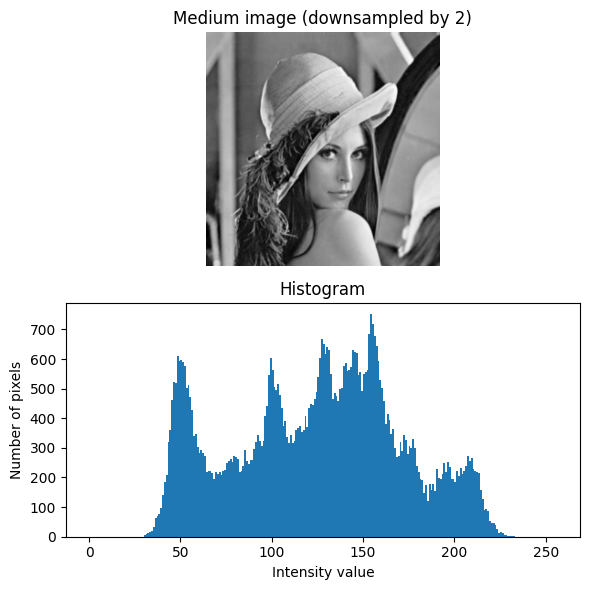

Medium shape: (256, 256)


In [31]:
# Step 2: Downsample by taking every 2nd pixel
# [::2, ::2] means: take every 2nd row and every 2nd column
r = 2
medium = fine_smooth[::r, ::r]

show_image(medium, "Medium image (downsampled by 2)", cmap="gray")
print("Medium shape:", medium.shape)

**observation:**
- dimensions are half in each direction: (512, 512) -> (256, 256)
- the face is still recognizable but smaller
- some fine detail is gone but major structure remains
- this is why smooth-then-downsample works: smoothing prepares the image so downsampling doesn't create artifacts

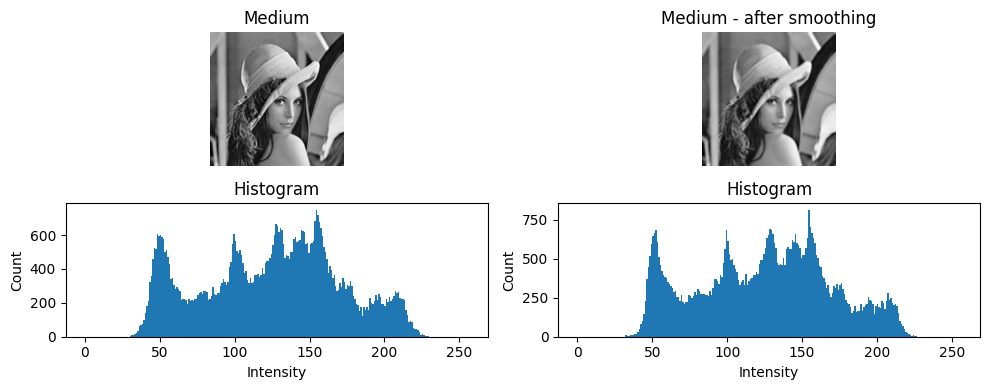

In [32]:
# Create the coarse level (repeat the process)
# Smooth the medium image
medium_smooth = cv2.GaussianBlur(medium, (5, 5), 1)

show_images(
    [medium, medium_smooth],
    ["Medium", "Medium - after smoothing"],
    cmap="gray",
    figsize=(10, 4)
)

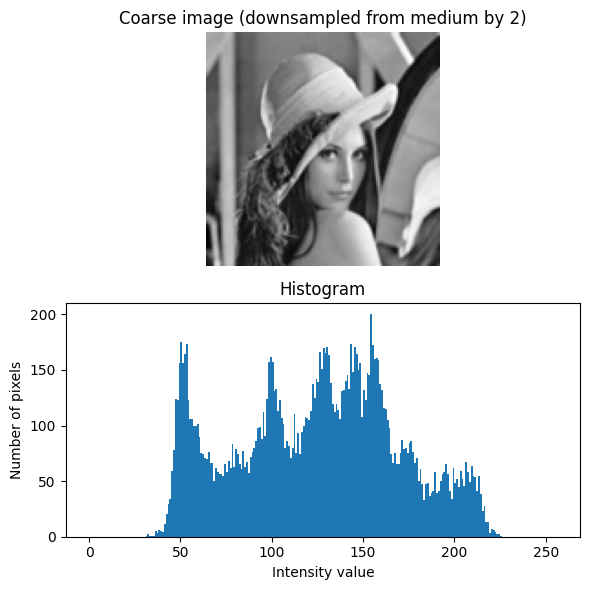

Coarse shape: (128, 128)


In [33]:
# Downsample again
coarse = medium_smooth[::r, ::r]

show_image(coarse, "Coarse image (downsampled from medium by 2)", cmap="gray")
print("Coarse shape:", coarse.shape)

**observation:**
- now we're at (128, 128) — really small
- still recognizable as a face but heavily pixelated
- only the largest structures remain (head shape, general feature positions)
- fine details like wrinkles are completely gone
- histogram is even more compressed now — we're down to maybe 50 distinct values

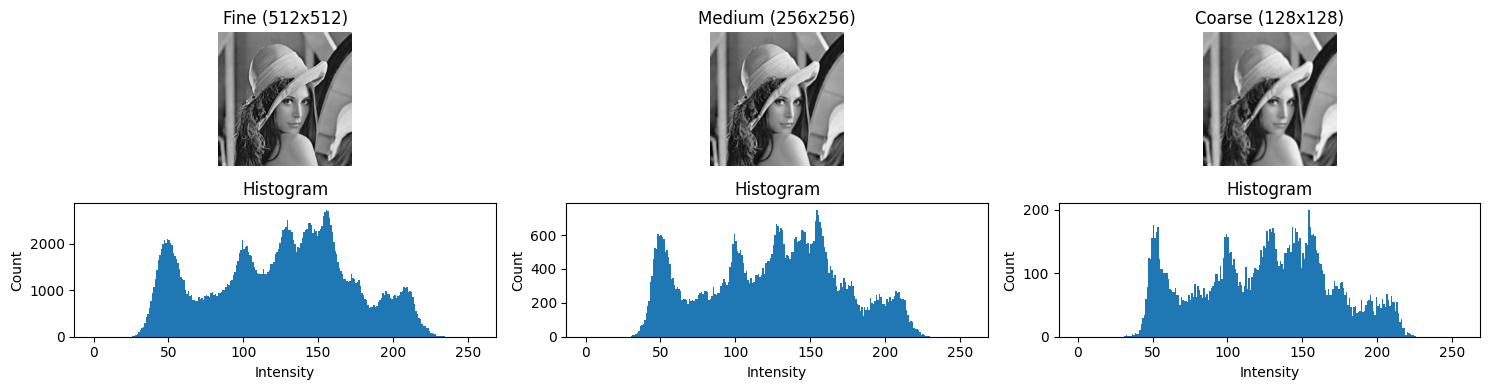


Pyramid summary:
Fine shape: (512, 512)
Medium shape: (256, 256)
Coarse shape: (128, 128)


In [34]:
# Show all three pyramid levels together
show_images(
    [fine, medium, coarse],
    ["Fine (512x512)", "Medium (256x256)", "Coarse (128x128)"],
    cmap="gray",
    figsize=(15, 4)
)

print("\nPyramid summary:")
print("Fine shape:", fine.shape)
print("Medium shape:", medium.shape)
print("Coarse shape:", coarse.shape)

**observation:** the progression is clear. each step, we lose detail but keep structure. this is exactly how multi-scale approaches work in computer vision — you can process at different scales and combine results.

In [35]:
# Save the pyramid levels
cv2.imwrite("../outputs/lenna_fine.png", fine)
cv2.imwrite("../outputs/lenna_medium.png", medium)
cv2.imwrite("../outputs/lenna_coarse.png", coarse)
print("Pyramid images saved")

Pyramid images saved


**Discussion: Pyramid construction**

1. **What happens to image dimensions at each stage?** Halved in each direction. 512x512 → 256x256 → 128x128. So the size becomes 1/4 (area-wise) at each step.

2. **What details are visible in fine but weaker in medium?** Wrinkles, skin texture, hair strands, small facial features. The fine detail that makes the face look realistic.

3. **What details disappear almost completely in coarse?** Everything except the basic head shape and major feature positions. All texture is gone.

4. **Why is smoothing done before downsampling?** If you just drop pixels without smoothing, you get aliasing (jagged artifacts) and information loss. Smoothing is a "preparation" step — it removes the high-frequency detail that would create artifacts when downsampled.

5. **Histogram changes from fine to medium to coarse?** 
   - Fine: full range of values (lots of variation in texture and detail)
   - Medium: slightly compressed (smoothing reduced local variation, resolution loss removed some high frequencies)
   - Coarse: highly compressed (mostly just large-scale structures remain, limited dynamic range)

This is really important for understanding multi-scale processing in computer vision.

### 4.2 Repeat pyramid with another image

now let me do the same pyramid with baboon. i expect it to behave differently since baboon has lots of texture.

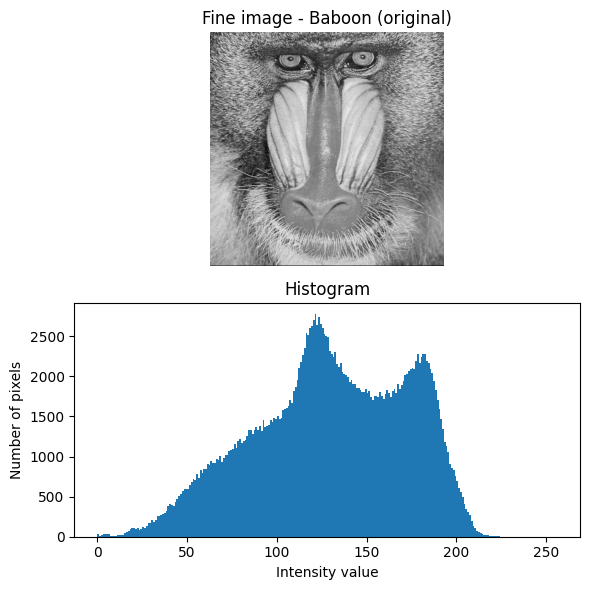

Fine shape: (512, 512)


In [36]:
# Start from baboon grayscale (fine level)
fine_b = baboon_gray.copy()

show_image(fine_b, "Fine image - Baboon (original)", cmap="gray")
print("Fine shape:", fine_b.shape)

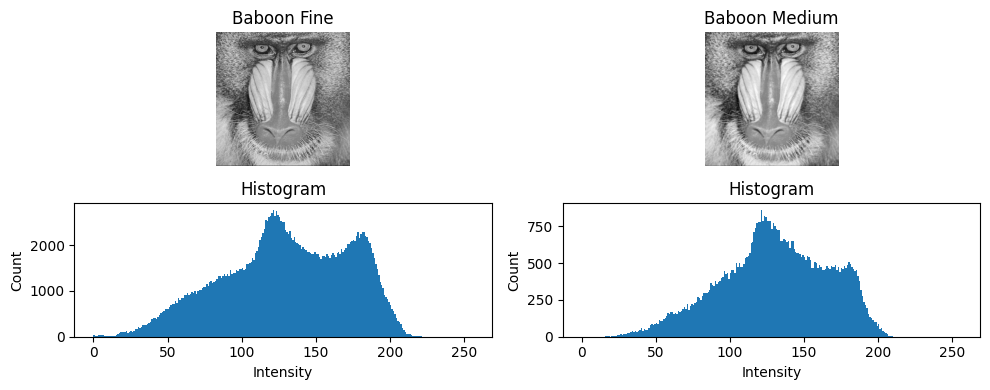

Medium shape: (256, 256)


In [37]:
# Create medium level
fine_smooth_b = cv2.GaussianBlur(fine_b, (5, 5), 1)
medium_b = fine_smooth_b[::r, ::r]

show_images(
    [fine_b, medium_b],
    ["Baboon Fine", "Baboon Medium"],
    cmap="gray",
    figsize=(10, 4)
)
print("Medium shape:", medium_b.shape)

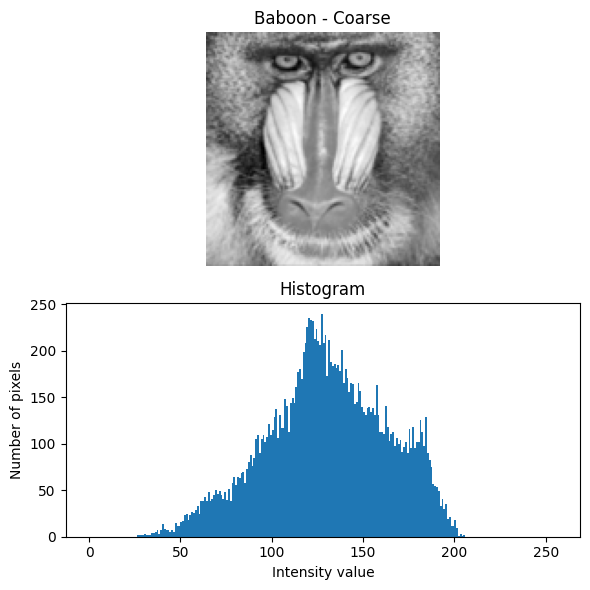

Coarse shape: (128, 128)


In [38]:
# Create coarse level
medium_smooth_b = cv2.GaussianBlur(medium_b, (5, 5), 1)
coarse_b = medium_smooth_b[::r, ::r]

show_image(coarse_b, "Baboon - Coarse", cmap="gray")
print("Coarse shape:", coarse_b.shape)

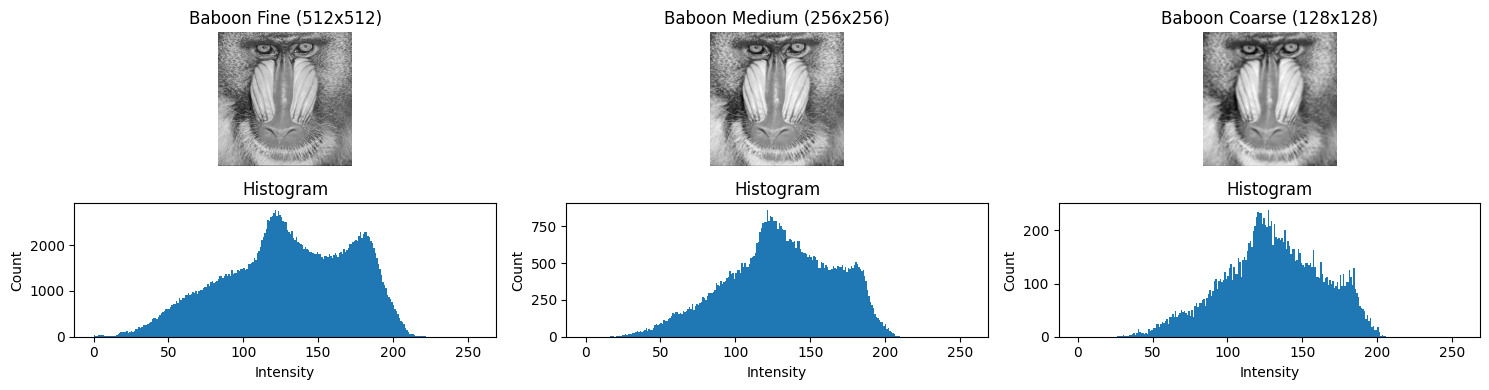


Baboon Pyramid summary:
Fine shape: (512, 512)
Medium shape: (256, 256)
Coarse shape: (128, 128)


In [39]:
# Show all three together
show_images(
    [fine_b, medium_b, coarse_b],
    ["Baboon Fine (512x512)", "Baboon Medium (256x256)", "Baboon Coarse (128x128)"],
    cmap="gray",
    figsize=(15, 4)
)

print("\nBaboon Pyramid summary:")
print("Fine shape:", fine_b.shape)
print("Medium shape:", medium_b.shape)
print("Coarse shape:", coarse_b.shape)

In [40]:
# Save baboon pyramid
cv2.imwrite("../outputs/baboon_fine.png", fine_b)
cv2.imwrite("../outputs/baboon_medium.png", medium_b)
cv2.imwrite("../outputs/baboon_coarse.png", coarse_b)
print("Baboon pyramid saved")

Baboon pyramid saved


**My observations on baboon pyramid vs lenna pyramid:**

The fine baboon image is covered in fur texture — it's very high-frequency detail. When we smooth and downsample:

- **Fine → Medium:** The fur texture COMPLETELY disappears! What was a detailed animal is now just shape and major feature boundaries. This is dramatic compared to lenna where smoothing just softens wrinkles.

- **Medium → Coarse:** We lose the details of the face and eyes. Now it's just a blob of medium darkness with a few darker patches.

The key difference: lenna is relatively smooth to begin with (skin tones), so the pyramid levels are subtle changes. Baboon is packed with texture, so each downsampling removes TONS of information.

The histograms tell the story too:
- Fine baboon: lots of variation (fur texture creates many different intensity values)
- Medium baboon: much compressed (texture is gone)
- Coarse baboon: extremely narrow (just a few dominant tones)

This shows that pyramids are especially effective for removing fine texture and keeping only structure — exactly what you want for object detection and multi-scale processing.

---
## Lab Summary and Key Takeaways

**What i learned in this lab:**

1. **Linear filtering** is powerful — it lets you blur, sharpen, and process images in meaningful ways. Every filter can be understood as applying a kernel through convolution.

2. **Histograms tell the story.** After every operation, i checked the histogram. Smoothing compresses it (values pull toward the average). Sharpening spreads it (differences get amplified). Edge detection creates bimodal histograms (mostly 0 and some bright edge pixels).

3. **Edges are everywhere.** Sobel and Canny are both looking for places where intensity changes fast. Canny is more sophisticated (thinning, hysteresis) but both use gradient-based approaches.

4. **Thresholds matter.** For Canny, changing low/high thresholds changes the result dramatically. This is true for most real applications — parameters are crucial.

5. **Smooth before downsample.** This is a RULE in image processing. Smooth first to remove high frequencies, then downsample. Otherwise you get aliasing and artifacts.

6. **Texture vs structure.** A pyramid clearly shows that texture is high-frequency detail. At coarse levels, only structure (large-scale stuff) remains. This is why multi-scale processing works.

7. **Different images behave differently.** Lenna is smooth (skin), baboon has texture (fur). So the same operations produce different perceptual effects. When processing real images, you need to understand what's in them.

**What's next:** Edge detection leads to contour detection and object boundaries. Multi-scale processing is used in feature detection and matching. Filtering is the foundation for literally every computer vision algorithm.